#   Keras Functional API Practice

Most cutting-edge models such as the transformer and `word2vec` require custom input layers and non-sequential modelling to some extent.
This exercise is to build familiarity with the TF2/Keras Functional API with more familiar simple data.

## Setting Up

In [1]:
import tensorflow as tf
import keras
import pandas as pd

2024-06-29 15:50:24.863379: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-06-29 15:50:24.925392: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-29 15:50:26.154597: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


##  What Data?

I wanted the UK QLFS initially but the UKDS website is not the easiest to access from a non-academic location outside the UK.
So here's the Canadian LFS May 2024 instead.

In [2]:
!wget --tries=5 --directory-prefix=../data --continue --timestamping https://www150.statcan.gc.ca/n1/en/pub/71m0001x/2021001/2024-05-CSV.zip

--2024-06-29 15:50:27--  https://www150.statcan.gc.ca/n1/en/pub/71m0001x/2021001/2024-05-CSV.zip
Resolving www150.statcan.gc.ca (www150.statcan.gc.ca)... 167.44.105.20
Connecting to www150.statcan.gc.ca (www150.statcan.gc.ca)|167.44.105.20|:443... connected.
HTTP request sent, awaiting response... 304 Not Modified
File ‘../data/2024-05-CSV.zip’ not modified on server. Omitting download.



Unzip

In [3]:
!rm -rf ../data/can_lfs
!unzip -q -d ../data/can_lfs ../data/2024-05-CSV.zip

Here's the March 2024 Monthly LFS of Canada.

In [4]:
df = pd.read_csv('../data/can_lfs/pub0524.csv')
df = df.rename(columns=str.lower)
df = df.rename(columns=str.strip)
df = df.set_index(keys=['rec_num'], append=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112971 entries, 1 to 112971
Data columns (total 59 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   survyear  112971 non-null  int64  
 1   survmnth  112971 non-null  int64  
 2   lfsstat   112971 non-null  int64  
 3   prov      112971 non-null  int64  
 4   cma       112971 non-null  int64  
 5   age_12    112971 non-null  int64  
 6   age_6     22525 non-null   float64
 7   sex       112971 non-null  int64  
 8   marstat   112971 non-null  int64  
 9   educ      112971 non-null  int64  
 10  mjh       67384 non-null   float64
 11  everwork  45587 non-null   float64
 12  ftptlast  6898 non-null    float64
 13  cowmain   74282 non-null   float64
 14  immig     112971 non-null  int64  
 15  naics_21  74282 non-null   float64
 16  noc_10    74282 non-null   float64
 17  noc_43    74282 non-null   float64
 18  yabsent   5083 non-null    float64
 19  wksaway   5083 non-null    float64
 20  payaway  

##  Some Wrangling

This isn't actually going to be an exercise in modelling labour properly, although obviously the model has to make some sense to be a good exercise.

Why labour: there are multiple potential outcomes to model.
(1) Labour force status (employed vs unemployed vs retired vs OLF)?; 
(2) If employed, what wage, and how many hours?

While ideally one would estimate a two-part model for employment status and wages, either the Functional API may require some tinkering to make it estimate a two-part model or else this would require something more than just the Functional API, which is beyond the purpose of this exercise.
Instead, for this exercise the 2 outputs will simply be hours worked and hourly wages (for employed workers only, excluding self-employed).

Onto the main part.
Data wrangling... for this exercise, the following variables are good for this exercise if present:
1.  Hours worked and hourly wage (targets).
2.  Education level.
3.  Age (NB: potential years in labour force is redundant if education level is proxied by years of education).
4.  Job characteristics (e.g., tenure, union membership, firm size, job rank, full/part-time status).
5.  Demographic information (e.g., gender, ethnicity, marital status, immigrant status, region of residence).
6.  Weights (important for estimating a representative model).

In [5]:
df = df.loc[df['lfsstat'].isin([1,2])&df['cowmain'].isin([1,2]),[
    'ahrsmain', 'hrlyearn', 
    'prov', 'cma', 'age_12', 'sex', 'marstat', 'immig', 'educ', 
    'tenure', 'ftptmain', 'permtemp', 'union', 
    'naics_21', 'noc_10', 'firmsize', 
    'finalwt'
]]
df

,ahrsmain,hrlyearn,prov,cma,age_12,sex,marstat,immig,educ,tenure,ftptmain,permtemp,union,naics_21,noc_10,firmsize,finalwt
rec_num,,,,,,,,,,,,,,,,,
2,240.0,2900.0,59,9,4,2,2,2,4,8.0,2.0,1.0,3.0,15.0,2.0,2.0,335
6,200.0,1655.0,35,0,4,2,6,3,5,1.0,2.0,2.0,3.0,18.0,6.0,2.0,211
7,400.0,4800.0,59,9,5,1,1,3,4,76.0,1.0,1.0,1.0,9.0,8.0,4.0,224
8,650.0,8877.0,35,0,7,1,1,3,5,207.0,1.0,1.0,3.0,13.0,7.0,4.0,132
9,400.0,2100.0,13,0,5,1,6,3,1,37.0,1.0,3.0,3.0,6.0,8.0,1.0,199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112964,400.0,2400.0,10,0,4,1,6,3,2,120.0,1.0,1.0,1.0,15.0,7.0,4.0,46
112967,500.0,8718.0,35,0,8,1,1,3,3,168.0,1.0,1.0,3.0,12.0,1.0,4.0,354
112968,320.0,1500.0,12,0,1,2,6,2,3,22.0,2.0,4.0,3.0,19.0,7.0,2.0,123


2 decimals implied for `hrlyearn` (Hourly Earnings).

In [6]:
df['hrlyearn'] = df['hrlyearn'].div(100)
df['hrlyearn'].describe()

count    58377.000000
mean        34.373965
std         18.625476
min          6.870000
25%         21.000000
50%         29.230000
75%         43.000000
max        205.130000
Name: hrlyearn, dtype: float64

This is not meant to be a hardcore exercise in modelling labour properly, so `educ` will be recoded to the usual number of years of education for that level instead of dummies.

In [7]:
df['educ'] = df['educ'].map({0: 8, 1: 10, 2: 12, 3: 14, 4: 15, 5: 16, 6: 18})
df['educ'].value_counts(dropna=False).sort_index()

educ
8       710
10     3716
12    10085
14     3213
15    20946
16    13196
18     6511
Name: count, dtype: int64

For the same reasons, recode `age` to the lower boundary of the age group.

In [8]:
df['age_12'] = df['age_12'].map({1: 15, 2: 20, 3: 25, 4: 30, 5: 35, 6: 40, 7: 45, 8: 50, 9: 55, 10: 60, 11: 65, 12: 70})
df = df.rename(columns={'age_12': 'age'})
df['age'].value_counts(dropna=False).sort_index()

age
15    2934
20    5018
25    5837
30    6629
35    6702
40    6724
45    6030
50    5950
55    5374
60    4397
65    1876
70     906
Name: count, dtype: int64

Most job characteristics variables need to be dummy encoded, except tenure.
1.  `ftpt`: Recode to single dummy for part-time (1 = part-time).
2.  `permtemp`: Recode to single dummy for temp (1 = temp).
3.  `union`: Recode to single dummy for union (1 = in union or covered by union).
4.  `firmsize`: Recode to 3 dummies for small (20-99 employees), medium (100-500 employess), large (501+ employees).

In [9]:
df['ftptmain'] = df['ftptmain'].map({1: 0, 2: 1})
df = df.rename(columns={'ftptmain': 'pt'})
df['pt'].value_counts(dropna=False).sort_index()

pt
0    48559
1     9818
Name: count, dtype: int64

In [10]:
df['permtemp'] = df['permtemp'].map({1: 0, 2: 1, 3: 1, 4: 1})
df = df.rename(columns={'permtemp': 'temp'})
df['temp'].value_counts(dropna=False).sort_index()

temp
0    51134
1     7243
Name: count, dtype: int64

In [11]:
df['union'] = df['union'].map({1: 1, 2: 1, 3: 0})
df['union'].value_counts(dropna=False).sort_index()

union
0    39512
1    18865
Name: count, dtype: int64

In [12]:
df['firm_sm'] = df['firmsize'].map({1: 0, 2: 1, 3: 0, 4: 0})
df['firm_md'] = df['firmsize'].map({1: 0, 2: 0, 3: 1, 4: 0})
df['firm_lg'] = df['firmsize'].map({1: 0, 2: 0, 3: 0, 4: 1})
df = df.drop(columns=['firmsize'])
df[['firm_sm', 'firm_md', 'firm_lg']].value_counts(dropna=False).sort_index()

firm_sm  firm_md  firm_lg
0        0        0          10156
                  1          29105
         1        0           9438
1        0        0           9678
Name: count, dtype: int64

Industry and Occupation will just be dummy encoded.

There is an issue though that the absence of this code leads to a prediction of unemployed by definition since this information is not collected for those who last worked more than 12 months ago.
For this reason, for now it would be best to only use it for wage prediction, not for LFStatus prediction.

In [13]:
df = df.rename(columns={'naics_21': 'naics', 'noc_10': 'noc'})
df = df.join(other=pd.get_dummies(df['naics'].convert_dtypes(), prefix='naics', drop_first=True, dtype='int'))
df = df.join(other=pd.get_dummies(df['noc'].convert_dtypes(), prefix='noc', drop_first=True, dtype='int'))
df = df.drop(columns=['naics', 'noc'])
df.loc[:,'naics_2':'noc_10'].agg(['count', 'sum', 'mean']).transpose().convert_dtypes()

,count,sum,mean
naics_2,58377,176,0.003015
naics_3,58377,177,0.003032
naics_4,58377,1200,0.020556
naics_5,58377,569,0.009747
naics_6,58377,3971,0.068023
naics_7,58377,2750,0.047108
naics_8,58377,2642,0.045258
naics_9,58377,1914,0.032787
naics_10,58377,6639,0.113726
naics_11,58377,2956,0.050636


Most demographic information also need to be encoded as dummies.
1.  `sex`: dummy for 1=female.
2.  `marstat`: 2 dummies: (1) 1=married, (2) 1=separated.
3.  `immig`: 2 dummies: (1) 1=recent immigrant, (2) 1=established immigrant.
4.  `prov` and `cma`: 1 dummy for each major CMA (9 major CMAs) and 1 for non-CMA regions of each province (10 provinces).

In [14]:
df['sex'] = df['sex'].map({1: 0, 2: 1})
df = df.rename(columns={'sex': 'female'})
df['female'].value_counts(dropna=False).sort_index()

female
0    29224
1    29153
Name: count, dtype: int64

In [15]:
df['mar_mar'] = df['marstat'].map({1: 1, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0})
df['mar_sep'] = df['marstat'].map({1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 0})
df = df.drop(columns=['marstat'])
df[['mar_mar', 'mar_sep']].value_counts(dropna=False).sort_index()

mar_mar  mar_sep
0        0          27052
         1           4478
1        0          26847
Name: count, dtype: int64

In [16]:
df['imm_new'] = df['immig'].map({1: 1, 2: 0, 3: 0})
df['imm_old'] = df['immig'].map({1: 0, 2: 1, 3: 0})
df = df.drop(columns=['immig'])
df[['imm_new', 'imm_old']].value_counts(dropna=False).sort_index()

imm_new  imm_old
0        0          45232
         1           8263
1        0           4882
Name: count, dtype: int64

In [17]:
df = df.join(other=pd.get_dummies(df['cma'], prefix='cma', drop_first=True, dtype='int'))
df = df.join(other=pd.get_dummies(df['prov'].where(df['cma'].isin([0]), 0), prefix='prov', drop_first=True, dtype='int'))
df = df.drop(columns=['prov', 'cma', 'prov_35'])
df.loc[:,'cma_1':'prov_59'].value_counts().sort_index()

cma_1  cma_2  cma_3  cma_4  cma_5  cma_6  cma_7  cma_8  cma_9  prov_10  prov_11  prov_12  prov_13  prov_24  prov_46  prov_47  prov_48  prov_59
0      0      0      0      0      0      0      0      0      0        0        0        0        0        0        0        0        0          10392
                                                                                                                                       1           3700
                                                                                                                              1        0           2215
                                                                                                                     1        0        0           3486
                                                                                                            1        0        0        0           1934
                                                                                                 

Final look at the variables in the dataset.

In [18]:
with pd.option_context('display.max_rows', None):
    display(df.agg(['dtype', 'count', 'nunique', 'mean', 'std', 'min', 'median', 'max']).transpose())

,dtype,count,nunique,mean,std,min,median,max
ahrsmain,float64,58377,381,329.26567,150.139895,0.0,375.0,990.0
hrlyearn,float64,58377,4658,34.373965,18.625476,6.87,29.23,205.13
age,int64,58377,12,39.506912,14.140277,15,40.0,70
female,int64,58377,2,0.499392,0.500004,0,0.0,1
educ,int64,58377,7,14.583929,2.203179,8,15.0,18
tenure,float64,58377,240,87.827483,82.395552,1.0,56.0,240.0
pt,int64,58377,2,0.168183,0.374032,0,0.0,1
temp,int64,58377,2,0.124073,0.329667,0,0.0,1
union,int64,58377,2,0.323158,0.467687,0,0.0,1
finalwt,int64,58377,1713,309.01653,285.394672,4,216.0,2636


##  Modelling

That's it for the data wrangling.
As mentioned before getting the labour model right isn't the main point of this exercise.

This will be a simple neural network model using the Functional API with a few features:
1.  Multiple input layers.
2.  Multiple output heads.
3.  Each output head inputs using different but partially overlapping feature sets.
4.  One output head is dependent on the prediction of other output heads.

### Input Set 1

Following the standard labour literature, to identify the effects of variables on each outcome separately there must be identifying instruments.
Identifying instruments are variables that can be assumed to be associated with one outcome but not others for any reason.
Therefore features can be thought of as comprising three sets:
1.  Common features.
2.  Identifiers of outcome 1.
3.  Identifiers of outcome 2.

For this exercise, the heroic assumptions are that education is associated with wages but not hours worked _ceteris paribus_, 
while marital status is associated with hours worked but not wages, _ceteris paribus_.
Everything else is common.

Some naming conventions to avoid confusion over the many similarly named items being created:
1.  `X_<>`/`y_<>`: varlists.
2.  `xtf_<>`/`ytf_<>`: `tf.Tensor`s of corresponding varlists.
3.  `_x_<>`: `keras.layer` input layers.
4.  `_<>`: Intermediate layers of the model.

In [19]:
X_common = [
    'age', 'female', 'tenure', 'pt', 'temp', 'union', 'firm_sm', 'firm_md', 'firm_lg', 
    'naics_2', 'naics_3', 'naics_4', 'naics_5', 'naics_6', 'naics_7', 'naics_8', 'naics_9', 'naics_10', 
    'naics_11', 'naics_12', 'naics_13', 'naics_14', 'naics_15', 'naics_16', 'naics_17', 'naics_18', 'naics_19', 'naics_20', 
    'naics_21', 
    'noc_2', 'noc_3', 'noc_4', 'noc_5', 'noc_6', 'noc_7', 'noc_8', 'noc_9', 'noc_10', 
    'imm_new', 'imm_old', 
    'cma_1', 'cma_2', 'cma_3', 'cma_4', 'cma_5', 'cma_6', 'cma_7', 'cma_8', 'cma_9', 
    'prov_10', 'prov_11', 'prov_12', 'prov_13', 'prov_24', 'prov_46', 'prov_47', 'prov_48', 'prov_59', 
]
K_X_COMMON = len(X_common)
xtf_common = tf.constant(df.loc[:,X_common], dtype='float32')
_x_common = keras.Input(shape=(K_X_COMMON,), name='common')

2024-06-29 15:50:30.814337: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-29 15:50:30.865071: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Input Set 2

Education.
For identifying wages.

In [20]:
X_wages = [
    'educ', 
]
K_X_WAGES = len(X_wages)
xtf_wages = tf.constant(df.loc[:,X_wages], dtype='float32')
_x_wages = keras.Input(shape=(K_X_WAGES,), name='educ')

### Input Set 3

Marital status.
For identifying hours.

In [21]:
X_hrs = [
    'mar_mar', 'mar_sep', 
]
K_X_HRS = len(X_hrs)
xtf_hrs = tf.constant(df.loc[:,X_hrs], dtype='float32')
_x_hrs = keras.Input(shape=(K_X_HRS,), name='marstat')

### Output 1

Wages - continuous regression.

In [22]:
y_earn = ['hrlyearn']
ytf_earn = tf.constant(df.loc[:,y_earn], dtype='float32')

### Output 2

Actual hours - also continuous regression.

In [23]:
y_ahrs = ['ahrsmain']
ytf_ahrs = tf.constant(df.loc[:,y_ahrs], dtype='float32')

### Dataset

Need this to actually estimate the model.

In [24]:
ds = tf.data.Dataset.from_tensor_slices(({'common': xtf_common, 'educ': xtf_wages, 'marstat': xtf_hrs}, {'wages': ytf_earn, 'hours': ytf_ahrs}))
ds_main, ds_test = keras.utils.split_dataset(ds, left_size=0.8, shuffle=True, seed=1234567)
ds_test = ds_test.batch(32)
ds_train, ds_val = keras.utils.split_dataset(ds, left_size=(7/8), shuffle=True, seed=2345678)
ds_train = ds_train.batch(32)
ds_val = ds_val.batch(32)

2024-06-29 15:50:44.493269: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-06-29 15:50:59.804258: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Hidden Layers

This is going to be really simple.
1.  First layer, each input layer is passed to their own dense layers.
2.  Second layer, two sets of layers that are fed from common + 1 of the other 2 inputs.
3.  Output layer, two sets that feed from 1 of the 2 second layers.

In [25]:
_x_1_1 = keras.layers.Dense(units=100, activation='relu')(_x_common)
_x_1_2 = keras.layers.Dense(units=5, activation='relu')(_x_wages)
_x_1_3 = keras.layers.Dense(units=5, activation='relu')(_x_hrs)

Second layer

In [26]:
_x_2_1 = keras.layers.Dense(units=100, activation='relu')(keras.layers.concatenate([_x_1_1, _x_1_2]))
_x_3_1 = keras.layers.Dense(units=100, activation='relu')(_x_2_1)
_x_2_2 = keras.layers.Dense(units=100, activation='relu')(keras.layers.concatenate([_x_1_1, _x_1_3]))
_x_3_2 = keras.layers.Dense(units=100, activation='relu')(_x_2_2)

Output layers

In [27]:
_x_4_1 = keras.layers.Dense(units=1, activation=None, name='wages')(_x_3_1)
_x_4_2 = keras.layers.Dense(units=1, activation=None, name='hours')(_x_3_2)

Model

In [28]:
model = keras.Model(inputs=[_x_common, _x_wages, _x_hrs], outputs=[_x_4_1, _x_4_2])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ common (InputLayer) │ (None, 58)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ educ (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ marstat             │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100)       │      5,900 │ common[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │         10 │ educ[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │         15 │ marstat[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 105)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 105)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 100)       │     10,600 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 100)       │     10,600 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 100)       │     10,100 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 100)       │     10,100 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wages (Dense)       │ (None, 1)         │        101 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hours (Dense)       │ (None, 1)         │        101 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,527 (185.65 KB)

 Trainable params: 47,527 (185.65 KB)

 Non-trainable params: 0 (0.00 B)

Compile

In [29]:
STEPS_PER_EPOCH = ds_train.cardinality().numpy()
##  Decay the LR by 10% every 10 epochs
##  By the 100th epoch the learning rate will only be 1% of the starting
lrschedule = keras.optimizers.schedules.ExponentialDecay(1e-3, decay_steps=10 * STEPS_PER_EPOCH, decay_rate=0.9)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=lrschedule), 
    loss=keras.losses.MeanSquaredError(), 
    metrics=[keras.metrics.R2Score(), keras.metrics.R2Score()])
earlystopping = keras.callbacks.EarlyStopping(start_from_epoch=3, patience=10, restore_best_weights=True)

Train

In [30]:
history = model.fit(ds_train, validation_data=ds_val, epochs=1000, callbacks=[earlystopping])

Epoch 1/1000
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - hours_r2_score: -0.4545 - loss: 32814.6562 - wages_r2_score: 0.0759 - val_hours_r2_score: -0.0719 - val_loss: 24942.4922 - val_wages_r2_score: 0.2646
Epoch 2/1000
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - hours_r2_score: 0.2156 - loss: 17784.1738 - wages_r2_score: 0.2832 - val_hours_r2_score: 0.0241 - val_loss: 22702.4316 - val_wages_r2_score: 0.3521
Epoch 3/1000
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - hours_r2_score: 0.2440 - loss: 17120.0781 - wages_r2_score: 0.3707 - val_hours_r2_score: 0.0756 - val_loss: 21497.8164 - val_wages_r2_score: 0.3990
Epoch 4/1000
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - hours_r2_score: 0.2561 - loss: 16836.5645 - wages_r2_score: 0.4113 - val_hours_r2_score: 0.1139 - val_loss: 20611.9570 - val_wages_r2_score: 0.4137
Epoch 5/1000
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - hours_r2_score: 0.2638 - loss: 16658.0449 - wages_r2_score: 0.4277 - val_hours_r2_score: 0.1392 - val_loss: 20030.76

Evaluate

In [31]:
model.evaluate(ds_test)

365/365 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - hours_r2_score: 0.3176 - loss: 15997.3770 - wages_r2_score: 0.4550


[15725.9404296875, 0.3142128586769104, 0.45717257261276245]

Performance is about the same as validation.
Did not overfit.

Low performance in general: model is underfitted.
Most likely due to insufficient information in the dataset to predict earnings and hours at this level of disaggregation.

In [46]:
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

Training curve

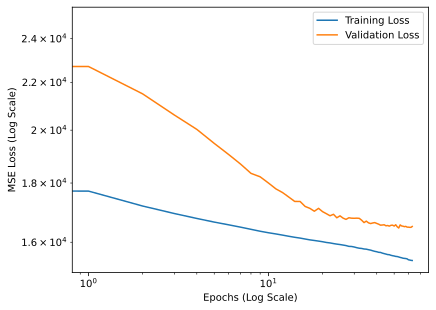

In [47]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.yscale('log')
plt.ylabel('MSE Loss (Log Scale)')
plt.xscale('log')
plt.xlabel('Epochs (Log Scale)')
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())

Metrics

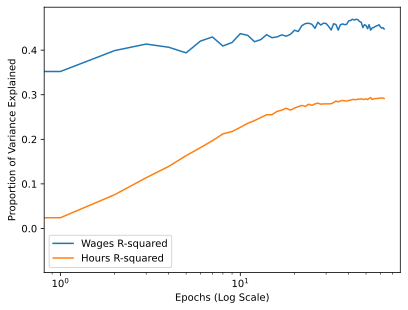

In [54]:
plt.plot(history.history['val_wages_r2_score'], label='Wages R-squared')
plt.plot(history.history['val_hours_r2_score'], label='Hours R-squared')
plt.legend()
plt.ylabel('Proportion of Variance Explained')
plt.xscale('log')
plt.xlabel('Epochs (Log Scale)')
plt.show()
plt.gcf().clear()
plt.close(plt.gcf())